# MS2PIP, DeepLC & IM2Deep: Multi-modal Peptide Property Prediction

**Tool versions:** ms2pip, deeplc, im2deep — latest PyPI releases (see install cell)
**Estimated time:** 20 min
**Level:** intermediate
**Last tested:** 2026-06-10

## Abstract

This tutorial predicts three complementary LC-IM-MS/MS properties for real HeLa-derived
peptides using CompOmics tools: fragment ion intensities with
[MS2PIP](https://github.com/compomics/ms2pip), retention time with
[DeepLC](https://github.com/compomics/DeepLC), and collisional cross-section with
[IM2Deep](https://github.com/compomics/IM2Deep). By the end, you will have produced a
predicted MS2 spectrum, a calibrated retention time scatter plot, and a CCS correlation
plot, each benchmarked against observed values from a public dataset.

| Tool | Prediction | Model |
|------|-----------|-------|
| [MS2PIP](https://github.com/compomics/ms2pip) | Fragment ion intensities (b/y) | HCD2021 |
| [DeepLC](https://github.com/compomics/DeepLC) | Retention time (RT) | Calibrated |
| [IM2Deep](https://github.com/compomics/IM2Deep) | Collisional cross-section (CCS) | Direct |

## Learning objectives

By the end of this tutorial, you will be able to:

- Convert MaxQuant modified-sequence notation to ProForma
- Predict fragment ion intensities with MS2PIP and interpret a predicted b/y-ion spectrum
- Calibrate and run DeepLC retention time predictions, and evaluate them against observed RT
- Predict CCS values with IM2Deep without calibration and evaluate them against observed CCS

## Prerequisites

- Familiarity with basic Python and pandas
- Basic understanding of peptide fragmentation (b/y-ions) and LC-MS/MS

## Input data

The [Meier *et al.* IM-CCS dataset](https://proteomicsml.org/datasets/ionmobility/Meier_IM_CCS/),
hosted on [ProteomicsML](https://proteomicsml.org). It was acquired on a timsTOF Pro
instrument and covers three ProteomeXchange depositions (PXD010012, PXD019086,
PXD017703): 718 K high-confidence PSMs with observed retention time and CCS. The
dataset (~23 MB) is downloaded directly from the ProteomicsML GitHub repository in
Section 2.

## 1. Setup

In [1]:
# Install dependencies (run once)
# !pip install ms2pip deeplc im2deep psm-utils tensorflow-cpu

In [2]:
import io
import re
import zipfile

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import requests
from scipy.stats import pearsonr

from deeplc import DeepLC
from im2deep import predict_ccs
from ms2pip import predict_batch
from psm_utils import PSM, PSMList

I0000 00:00:1781103491.484486  615873 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781103492.782190  615873 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
%matplotlib inline

## 2. Dataset

The [Meier *et al.* IM-CCS dataset](https://proteomicsml.org/datasets/ionmobility/Meier_IM_CCS/)
was acquired on a timsTOF Pro instrument and covers three ProteomeXchange depositions
(PXD010012, PXD019086, PXD017703). It contains 718 K high-confidence PSMs with four
key measured properties:

| Column | Description |
|--------|-------------|
| `Modified sequence` | MaxQuant notation: underscores mark the termini, modifications in parentheses, e.g. `_AAEM(ox)K_` |
| `Charge` | Precursor charge state |
| `Retention time` | In **seconds** when `PT=False` (standard 120 min gradient); in minutes when `PT=True` |
| `CCS` | Collisional cross-section in Å², measured by TIMS |
| `PT` | `True` = phosphopeptide-enriched short gradient; `False` = standard proteome run |

We download the dataset directly from the ProteomicsML GitHub repository.

In [4]:
url = (
    "https://raw.githubusercontent.com/ProteomicsML/ProteomicsML/main"
    "/datasets/ionmobility/Meier_IM_CCS/combined_sm.zip"
)

print("Downloading dataset (~23 MB)...")
response = requests.get(url, timeout=120)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df_raw = pd.read_csv(z.open("combined_sm.csv"))

print(f"Loaded {len(df_raw):,} PSMs")
df_raw.head()

Loaded 718,917 PSMs


,Unnamed: 0,Modified sequence,Charge,Mass,Intensity,Retention time,CCS,PT
0,0,_(ac)AAAAAAAAAAGAAGGR_,2,1239.63200,149810.0,70.140,409.092529,False
1,1,_(ac)AAAAAAAAEQQSSNGPVKK_,2,1810.91734,21349.0,19.645,481.229248,True
2,2,_(ac)AAAAAAAGAAGSAAPAAAAGAPGSGGAPSGSQGVLIGDR_,3,3144.55482,194000.0,3947.700,772.098083,False
3,3,_(ac)AAAAAAAGDSDSWDADAFSVEDPVRK_,2,2634.18340,6416400.0,94.079,573.213196,False
4,4,_(ac)AAAAAAAGDSDSWDADAFSVEDPVRK_,3,2634.18340,5400600.0,94.841,635.000549,False


## 3. Preprocessing

We apply the following steps:

1. **Filter** to charge-2 PSMs from the 120 min gradient runs (`PT=False`), keeping RTs
   between 10 and 110 min (600–6600 s), and removing peptides shorter than 8 or longer
   than 20 residues. This gives a representative set of well-measured tryptic peptides
   across the gradient.
2. **Convert** MaxQuant modified sequences to [ProForma](https://github.com/HUPO-PSI/ProForma)
   notation, which is the unified format accepted by all three tools. For example:
   `_AAEM(ox)K_` (charge 2) → `AAEM[Oxidation]K/2`
   Modifications are placed in square brackets immediately after the modified residue;
   the charge state follows a `/` suffix. N-terminal modifications use a `-` separator,
   e.g. `_(ac)PEPTIDE_` → `[Acetyl]-PEPTIDE/2`.
3. **Sample** 200 PSMs for the predictions.

In [5]:
MQ_MOD_MAP = {
    "ac": "Acetyl",
    "ox": "Oxidation",
    "ca": "Carbamidomethyl",
    "de": "Deamidated",
    "ph": "Phospho",
}


def mq_to_proforma(mq_seq: str, charge: int) -> str:
    """Convert MaxQuant modified sequence to ProForma notation."""
    seq = mq_seq.strip("_")
    nterm_m = re.match(r"^\((\w+)\)", seq)
    nterm = ""
    if nterm_m:
        nterm = f"[{MQ_MOD_MAP.get(nterm_m.group(1), nterm_m.group(1))}]-"
        seq = seq[nterm_m.end() :]
    seq = re.sub(
        r"\((\w+)\)",
        lambda m: f"[{MQ_MOD_MAP.get(m.group(1), m.group(1))}]",
        seq,
    )
    return f"{nterm}{seq}/{charge}"


# Filter
data = df_raw[
    (df_raw["PT"] == False)
    & df_raw["Retention time"].between(600, 6600)
    & (df_raw["Charge"] == 2)
].copy()

data["proforma"] = data.apply(
    lambda r: mq_to_proforma(r["Modified sequence"], r["Charge"]), axis=1
)
data["sequence"] = (
    data["Modified sequence"].str.strip("_").str.replace(r"\(\w+\)", "", regex=True)
)
data["rt_min"] = data["Retention time"] / 60
data = data[data["sequence"].str.len().between(8, 20)]

sample = data.sample(200, random_state=42).reset_index(drop=True)
print(f"Filtered dataset: {len(data):,} PSMs")
print(f"Working sample:   {len(sample)} PSMs")
sample[["Modified sequence", "proforma", "rt_min", "CCS"]].head()

Filtered dataset: 36,477 PSMs
Working sample:   200 PSMs


,Modified sequence,proforma,rt_min,CCS
0,_NQHLQEQVAM(ox)QR_,NQHLQEQVAM[Oxidation]QR/2,14.670333,415.277649
1,_DVAAAAADSPNK_,DVAAAAADSPNK/2,14.732667,348.645264
2,_ASSQVNVEGQSR_,ASSQVNVEGQSR/2,16.557833,365.347382
3,_M(ox)PLLELGGETTPPLSTER_,M[Oxidation]PLLELGGETTPPLSTER/2,67.748333,464.870453
4,_DPSGDFSVR_,DPSGDFSVR/2,29.218333,328.006927


## 4. MS2PIP: Fragment Ion Intensity Prediction

[MS2PIP](https://github.com/compomics/ms2pip) predicts the relative intensities of
b- and y-fragment ions produced by collisional fragmentation (HCD). The two ion series
are complementary: b-ions retain the peptide N-terminus, y-ions retain the C-terminus.
For tryptic peptides ending in Lys or Arg, the y-ion series is typically dominant because
the basic C-terminal residue stabilises the y-ion charge.

We use the `HCD2021` model, which was trained on a large HCD fragmentation dataset and
supports unmodified and commonly modified peptides (oxidation, carbamidomethylation,
acetylation, phosphorylation).

All 200 peptides are predicted in a single `predict_batch` call. The model returns
log₂-transformed intensities, which we convert back with `2 ** intensity`.

> **Note**: the Meier dataset contains only RT and CCS values, not raw MS2 spectra.
> The predicted spectra below are therefore shown without an observed counterpart.

In [6]:
psm_list = PSMList(
    psm_list=[
        PSM(
            peptidoform=row["proforma"],
            spectrum_id=str(i),
            retention_time=row["rt_min"],
        )
        for i, row in sample.iterrows()
    ]
)

results = list(predict_batch(psm_list, model="HCD2021"))
print(f"MS2PIP: {len(results)} peptides predicted")

ms2pip_rows = []
for i, result in enumerate(results):
    for ion_type in ("b", "y"):
        for pos, (mz, intensity) in enumerate(
            zip(result.theoretical_mz[ion_type], result.predicted_intensity[ion_type]),
            start=1,
        ):
            ms2pip_rows.append(
                {
                    "sample_idx": i,
                    "ion_type": ion_type,
                    "position": pos,
                    "mz": float(mz),
                    "intensity": 2 ** float(intensity),
                }
            )

ms2pip_df = pd.DataFrame(ms2pip_rows)
print(f"Total ions predicted: {len(ms2pip_df):,}")

MS2PIP: 200 peptides predicted
Total ions predicted: 4,524


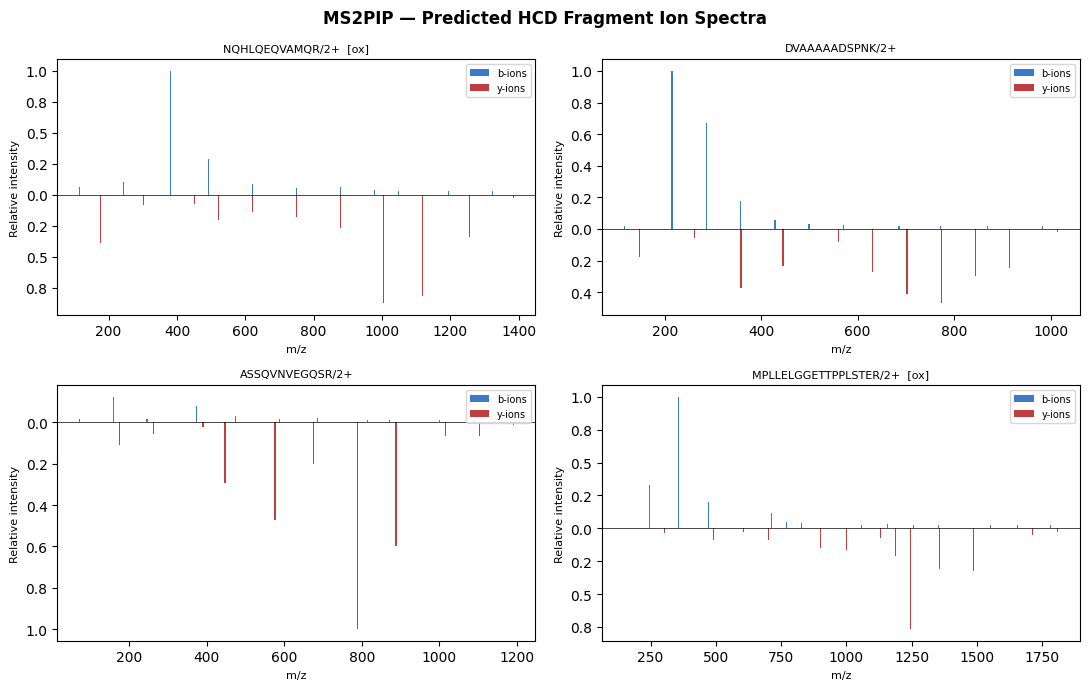

In [7]:
def plot_predicted_spectrum(ax, sample_idx, ms2pip_df, row):
    pep = ms2pip_df[ms2pip_df["sample_idx"] == sample_idx]
    b_ions = pep[pep["ion_type"] == "b"].sort_values("mz")
    y_ions = pep[pep["ion_type"] == "y"].sort_values("mz")
    max_int = max(b_ions["intensity"].max(), y_ions["intensity"].max())
    ax.bar(
        b_ions["mz"],
        b_ions["intensity"] / max_int,
        width=3,
        color="#1565C0",
        alpha=0.85,
        label="b-ions",
    )
    ax.bar(
        y_ions["mz"],
        -(y_ions["intensity"] / max_int),
        width=3,
        color="#B71C1C",
        alpha=0.85,
        label="y-ions",
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("m/z", fontsize=8)
    ax.set_ylabel("Relative intensity", fontsize=8)
    mods = re.findall(r"\((\w+)\)", row["Modified sequence"])
    mod_str = f"  [{', '.join(set(mods))}]" if mods else ""
    ax.set_title(f"{row['sequence']}/{int(row['Charge'])}+{mod_str}", fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{abs(x):.1f}"))
    ax.legend(fontsize=7, loc="upper right")


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, idx in zip(axes.flat, range(4)):
    plot_predicted_spectrum(ax, idx, ms2pip_df, sample.iloc[idx])

fig.suptitle(
    "MS2PIP — Predicted HCD Fragment Ion Spectra", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 5. DeepLC: Retention Time Prediction

[DeepLC](https://github.com/compomics/DeepLC) predicts peptide retention time using a
convolutional neural network. The model encodes the peptide as a series of overlapping
3-mer amino acid windows, with modification information embedded at each position.

Because RT depends on the specific LC gradient, column chemistry, and instrument setup,
DeepLC outputs are in model-relative units. **Calibration** is required to map these to
the observed gradient. During calibration, a monotonic spline is fitted to a set of
anchor PSMs with known RTs, and this spline is applied to all subsequent predictions.

DeepLC accepts a `PSMList` directly — the `retention_time` field on each PSM provides
the observed RT used for calibration. We use 50 randomly selected PSMs as anchors
and predict all 200.

> **Practical note**: in a real analysis you would typically use hundreds of
> confidently identified PSMs from the same LC run as calibration anchors.
> Here we use 50 for demonstration purposes.

In [8]:
# Select 50 anchor PSMs for calibration (retention_time already set)
cal_indices = sample.sample(50, random_state=7).index.tolist()
cal_psm_list = PSMList(psm_list=[psm_list[i] for i in cal_indices])

dlc = DeepLC()
dlc.calibrate_preds(psm_list=cal_psm_list)
pred_rt = np.array(dlc.make_preds(psm_list=psm_list, calibrate=True))

obs_rt = sample["rt_min"].values
mae_rt = np.mean(np.abs(pred_rt - obs_rt))
r_rt, _ = pearsonr(pred_rt, obs_rt)
print(f"DeepLC   MAE = {mae_rt:.2f} min  |  Pearson r = {r_rt:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


DeepLC   MAE = 3.86 min  |  Pearson r = 0.9696


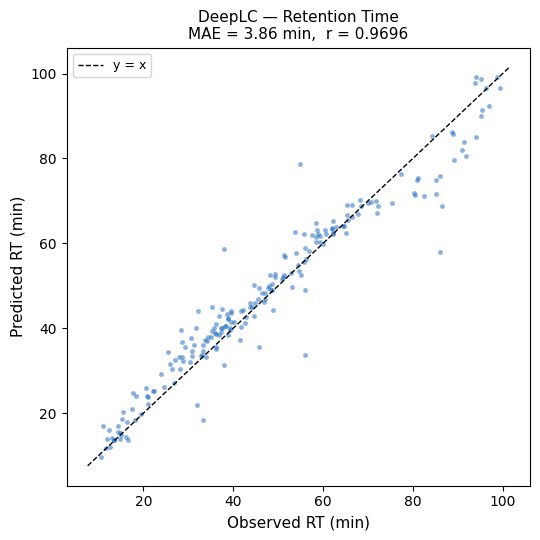

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(obs_rt, pred_rt, alpha=0.5, s=12, color="#1565C0", linewidths=0)
lo = min(obs_rt.min(), pred_rt.min()) - 2
hi = max(obs_rt.max(), pred_rt.max()) + 2
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x")
ax.set_xlabel("Observed RT (min)", fontsize=11)
ax.set_ylabel("Predicted RT (min)", fontsize=11)
ax.set_title(
    f"DeepLC — Retention Time\nMAE = {mae_rt:.2f} min,  r = {r_rt:.4f}",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the RT prediction

Each point is one PSM; the dashed line is the ideal y = x diagonal. Scatter around
the diagonal reflects prediction error. A Pearson r close to 1 means the model
correctly ranks peptides by elution order; MAE quantifies the absolute error in minutes.

For a 120 min gradient, MAE ≈ 4 min corresponds to a relative error of roughly 4 %.
This is sufficient for downstream applications such as peptide rescoring (Percolator,
MS²Rescore) and DIA library generation, where the goal is accurate rank ordering rather
than exact minute-level placement.

Systematic curvature in the scatter (S-shaped residuals) would indicate that the
calibration spline needs more anchor PSMs or a wider RT range to anchor on.


## 6. IM2Deep: Collisional Cross-Section Prediction

[IM2Deep](https://github.com/compomics/IM2Deep) predicts the collisional cross-section
(CCS) of peptide ions. CCS is a measure of how a peptide ion's three-dimensional shape
affects its drift time through a buffer gas in an ion mobility device. It is an intrinsic
physicochemical property of a peptide ion at a given charge state and does not depend on
the LC gradient — which is why IM2Deep can predict **absolute CCS values without
calibration**.

CCS is measured on timsTOF instruments using trapped ion mobility spectrometry (TIMS).
Combined with RT, it provides a second orthogonal dimension for peptide identification
and scoring. IM2Deep uses the same architecture and `PSMList` interface as DeepLC.

In [10]:
# Reuse the PSMList built for MS2PIP (includes charge encoded in ProForma string)
pred_ccs = predict_ccs(psm_list).values
obs_ccs = sample["CCS"].values

mare_ccs = np.mean(np.abs(pred_ccs - obs_ccs) / obs_ccs) * 100
r_ccs, _ = pearsonr(pred_ccs, obs_ccs)
print(f"IM2Deep  MARE = {mare_ccs:.2f}%  |  Pearson r = {r_ccs:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


IM2Deep  MARE = 1.38%  |  Pearson r = 0.9869


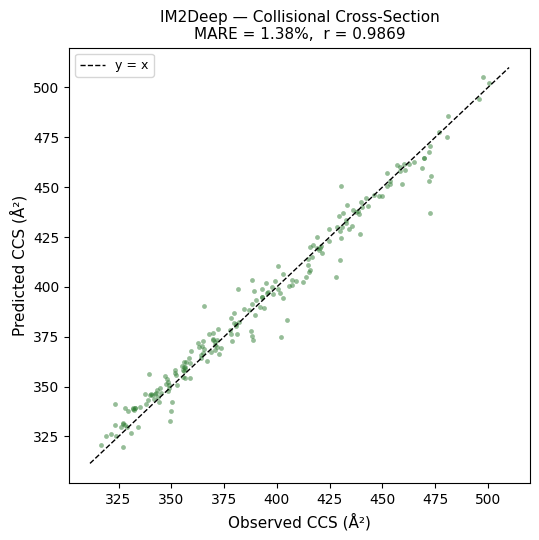

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(obs_ccs, pred_ccs, alpha=0.5, s=12, color="#2E7D32", linewidths=0)
lo = min(obs_ccs.min(), pred_ccs.min()) - 5
hi = max(obs_ccs.max(), pred_ccs.max()) + 5
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x")
ax.set_xlabel("Observed CCS (Å²)", fontsize=11)
ax.set_ylabel("Predicted CCS (Å²)", fontsize=11)
ax.set_title(
    f"IM2Deep — Collisional Cross-Section\nMARE = {mare_ccs:.2f}%,  r = {r_ccs:.4f}",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the CCS prediction

CCS values for doubly charged tryptic peptides typically fall between 300 and 550 Å²,
with larger peptides having higher CCS. The tight clustering around the diagonal
(MARE < 2 %) reflects that CCS is largely determined by amino acid composition and
sequence — properties that the model captures well.


## Key points

- MS2PIP, DeepLC, and IM2Deep all consume peptides in ProForma notation and predict a
  distinct physicochemical property from the sequence and charge state alone.
- DeepLC's retention time predictions are model-relative and must be calibrated against
  a set of anchor PSMs with known RT before they are meaningful for a specific LC gradient.
- IM2Deep's CCS predictions require no calibration, because CCS is an intrinsic property
  of the peptide ion rather than a function of the LC gradient.
- Together, these three predictors provide the feature set needed to build in silico
  spectral libraries or to rescore PSMs (see the [MS²Rescore tutorial](../posts/2026-06-11-ms2rescore.qmd)).

## Next steps

- [MS²Rescore tutorial](../posts/2026-06-11-ms2rescore.qmd): use these predictors as
  features to rescore real PSMs and improve identifications at a fixed FDR.
- [MS2PIP documentation](https://ms2pip.readthedocs.io)
- [DeepLC documentation](https://deeplc.readthedocs.io)
- [IM2Deep repository](https://github.com/compomics/IM2Deep)

## References

- Gabriels *et al.*, *Nucleic Acids Research* (2019). MS²PIP.
  [doi:10.1093/nar/gkz299](https://doi.org/10.1093/nar/gkz299)
- Bouwmeester *et al.*, *Nature Methods* (2021). DeepLC.
  [doi:10.1038/s41592-021-01301-5](https://doi.org/10.1038/s41592-021-01301-5)
- Meier *et al.*, *Nature Communications* (2021). Source dataset (timsTOF IM-CCS).
  [doi:10.1038/s41467-021-21352-8](https://doi.org/10.1038/s41467-021-21352-8)